Predictive Modeling and Statistical Decomposition of Urban Traffic Collision Severity Using Multi-Source Temporal Crash Data

Name:Rami Baggash
PRN:25070126138
Name:Sakher Shabil
PRN:25070126150

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
casualties = pd.read_csv("/content/dft-road-casualty-statistics-casualty-last-5-years.csv", low_memory=False)


In [ ]:
collisions = pd.read_csv("/content/dft-road-casualty-statistics-collision-last-5-years.csv", low_memory=False)

In [ ]:
vehicles = pd.read_csv("/content/dft-road-casualty-statistics-vehicle-last-5-years.csv", low_memory=False)

In [ ]:
casualties.head()

,collision_index,collision_year,collision_ref_no,vehicle_reference,casualty_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,casualty_severity,...,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_imd_decile,lsoa_of_casualty,enhanced_casualty_severity,casualty_injury_based,casualty_adjusted_severity_serious,casualty_adjusted_severity_slight,casualty_distance_banding
0,2020010280094,2020,010280094,1,1,3,2,24,5,3,...,0,0,0,3,E01003536,-1,0,0.0,1.0,-1
1,202031D109620,2020,31D109620,1,1,3,2,95,11,2,...,0,0,0,6,E01028156,-1,0,1.0,0.0,-1
2,2020401003715,2020,401003715,1,1,3,1,39,7,3,...,0,0,0,2,E01017492,3,1,0.0,1.0,-1
3,2021201086330,2021,201086330,1,1,3,1,63,9,3,...,0,2,0,3,E01009140,3,1,0.0,1.0,-1
4,2021371050963,2021,371050963,1,1,3,1,51,8,3,...,0,0,0,9,E01030190,3,1,0.0,1.0,-1


In [ ]:
collisions.head()


,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,...,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
0,2021170H10421,2021,170H10421,447098.0,532997.0,-1.270905,54.689833,17,3,2,...,0,0,2,1,2,E01011959,-1,0,0.293588,0.706412
1,2021170H11231,2021,170H11231,450486.0,533118.0,-1.218333,54.690592,17,3,2,...,0,0,1,2,2,E01011973,-1,0,0.017448,0.982552
2,2020170M11750,2020,170M11750,449694.0,519733.0,-1.232884,54.570397,17,3,2,...,0,0,1,1,2,E01012092,-1,0,0.128730,0.871270
3,2021170M31761,2021,170M31761,449744.0,514217.0,-1.233040,54.520825,17,3,1,...,0,0,2,1,2,E01032553,-1,0,0.182698,0.817302
4,2021170S10441,2021,170S10441,445971.0,520834.0,-1.290292,54.580641,17,3,3,...,0,13,2,1,1,E01012258,-1,0,0.016094,0.983906


In [ ]:
vehicles.head()

,collision_index,collision_year,collision_ref_no,vehicle_reference,vehicle_type,towing_and_articulation,vehicle_manoeuvre_historic,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,...,age_of_driver,age_band_of_driver,engine_capacity_cc,propulsion_code,age_of_vehicle,generic_make_model,driver_imd_decile,lsoa_of_driver,escooter_flag,driver_distance_banding
0,2020210979534,2020,210979534,2,5,0,3,3,4,6,...,57,9,798,1,4,BMW F 800,3,E01010422,0,-1
1,2020030959800,2020,030959800,1,5,0,17,19,2,6,...,59,9,798,1,3,BMW F 800,6,E01025351,0,-1
2,2020360978858,2020,360978858,2,5,0,18,19,8,4,...,64,9,798,1,11,BMW F 800,4,E01026874,0,-1
3,2020430340711,2020,430340711,1,5,0,18,19,3,7,...,48,8,798,1,8,BMW F 800,8,E01017758,0,-1
4,2020010260297,2020,010260297,1,5,0,99,99,9,9,...,36,7,798,1,9,BMW F 800,8,E01016121,0,-1


In [ ]:
casualties.shape

(640522, 23)

In [ ]:
collisions.shape

(503475, 44)

In [ ]:
vehicles.shape

(920692, 32)

In [ ]:
casualties.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640522 entries, 0 to 640521
Data columns (total 23 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   collision_index                     640522 non-null  object 
 1   collision_year                      640522 non-null  int64  
 2   collision_ref_no                    640522 non-null  object 
 3   vehicle_reference                   640522 non-null  int64  
 4   casualty_reference                  640522 non-null  int64  
 5   casualty_class                      640522 non-null  int64  
 6   sex_of_casualty                     640522 non-null  int64  
 7   age_of_casualty                     640522 non-null  int64  
 8   age_band_of_casualty                640522 non-null  int64  
 9   casualty_severity                   640522 non-null  int64  
 10  pedestrian_location                 640522 non-null  int64  
 11  pedestrian_movement       

In [ ]:
collisions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503475 entries, 0 to 503474
Data columns (total 44 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   collision_index                                   503475 non-null  object 
 1   collision_year                                    503475 non-null  int64  
 2   collision_ref_no                                  503475 non-null  object 
 3   location_easting_osgr                             503410 non-null  float64
 4   location_northing_osgr                            503410 non-null  float64
 5   longitude                                         503410 non-null  float64
 6   latitude                                          503410 non-null  float64
 7   police_force                                      503475 non-null  int64  
 8   collision_severity                                503475 non-null  int64  
 9   numb

In [ ]:
vehicles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920692 entries, 0 to 920691
Data columns (total 32 columns):
 #   Column                                     Non-Null Count   Dtype 
---  ------                                     --------------   ----- 
 0   collision_index                            920692 non-null  object
 1   collision_year                             920692 non-null  int64 
 2   collision_ref_no                           920692 non-null  object
 3   vehicle_reference                          920692 non-null  int64 
 4   vehicle_type                               920692 non-null  int64 
 5   towing_and_articulation                    920692 non-null  int64 
 6   vehicle_manoeuvre_historic                 920692 non-null  int64 
 7   vehicle_manoeuvre                          920692 non-null  int64 
 8   vehicle_direction_from                     920692 non-null  int64 
 9   vehicle_direction_to                       920692 non-null  int64 
 10  vehicle_location_res

In [ ]:
collisions.isnull().sum()

,0
collision_index,0
collision_year,0
collision_ref_no,0
location_easting_osgr,65
location_northing_osgr,65
longitude,65
latitude,65
police_force,0
collision_severity,0
number_of_vehicles,0


In [ ]:
vehicles.isnull().sum()

,0
collision_index,0
collision_year,0
collision_ref_no,0
vehicle_reference,0
vehicle_type,0
towing_and_articulation,0
vehicle_manoeuvre_historic,0
vehicle_manoeuvre,0
vehicle_direction_from,0
vehicle_direction_to,0


In [ ]:
casualties.isnull().sum()

,0
collision_index,0
collision_year,0
collision_ref_no,0
vehicle_reference,0
casualty_reference,0
casualty_class,0
sex_of_casualty,0
age_of_casualty,0
age_band_of_casualty,0
casualty_severity,0


In [ ]:
collisions.isnull().sum()[collisions.isnull().sum() > 0]

,0
location_easting_osgr,65
location_northing_osgr,65
longitude,65
latitude,65
local_authority_highway_current,80


In [ ]:
vehicles.isnull().sum()[vehicles.isnull().sum() > 0]

,0


In [ ]:
casualties.isnull().sum()[casualties.isnull().sum() > 0]

,0


In [ ]:
collisions.duplicated().sum()

np.int64(0)

In [ ]:
vehicles.duplicated().sum()

np.int64(0)

In [ ]:
casualties.duplicated().sum()

np.int64(0)

In [ ]:
(collisions == -1).sum().sum()

np.int64(1445559)

In [ ]:
(vehicles == -1).sum().sum()

np.int64(2391201)

In [ ]:
(casualties == -1).sum().sum()

np.int64(923484)

In [ ]:
collisions.replace(-1, np.nan, inplace=True)

In [ ]:
vehicles.replace(-1, np.nan, inplace=True)

In [ ]:
casualties.replace(-1, np.nan, inplace=True)

In [ ]:
(collisions == -1).sum().sum()

np.int64(0)

In [ ]:
(vehicles == -1).sum().sum()

np.int64(0)

In [ ]:
(casualties == -1).sum().sum()

np.int64(0)

In [ ]:
collisions.isnull().sum()[collisions.isnull().sum() > 0]

,0
location_easting_osgr,65
location_northing_osgr,65
longitude,65
latitude,65
local_authority_district,413073
local_authority_highway_current,80
speed_limit,15
junction_detail_historic,59607
junction_detail,14791
junction_control,211708


In [ ]:
vehicles.isnull().sum()[vehicles.isnull().sum() > 0]

,0
vehicle_type,6545
towing_and_articulation,7500
vehicle_manoeuvre_historic,117314
vehicle_manoeuvre,12335
vehicle_direction_from,18680
vehicle_direction_to,18810
vehicle_location_restricted_lane_historic,115031
vehicle_location_restricted_lane,10637
junction_location,4196
skidding_and_overturning,10093


In [ ]:
casualties.isnull().sum()[casualties.isnull().sum() > 0]

,0
sex_of_casualty,5740
age_of_casualty,13846
age_band_of_casualty,13846
pedestrian_location,14
pedestrian_movement,13
car_passenger,2737
bus_or_coach_passenger,255
pedestrian_road_maintenance_worker,12077
casualty_type,4935
casualty_imd_decile,69483


In [ ]:
#Small Missing
# Numerical → MEDIAN
collisions['location_easting_osgr'].fillna(collisions['location_easting_osgr'].median(), inplace=True)
collisions['location_northing_osgr'].fillna(collisions['location_northing_osgr'].median(), inplace=True)
collisions['longitude'].fillna(collisions['longitude'].median(), inplace=True)
collisions['latitude'].fillna(collisions['latitude'].median(), inplace=True)
collisions['speed_limit'].fillna(collisions['speed_limit'].median(), inplace=True)

# Categorical → MODE
collisions['light_conditions'].fillna(collisions['light_conditions'].mode()[0], inplace=True)
collisions['weather_conditions'].fillna(collisions['weather_conditions'].mode()[0], inplace=True)
collisions['urban_or_rural_area'].fillna(collisions['urban_or_rural_area'].mode()[0], inplace=True)
collisions['did_police_officer_attend_scene_of_accident'].fillna(collisions['did_police_officer_attend_scene_of_accident'].mode()[0], inplace=True)
collisions['local_authority_highway_current'].fillna(collisions['local_authority_highway_current'].mode()[0],inplace=True)
collisions['carriageway_hazards'].fillna(collisions['carriageway_hazards'].mode()[0],inplace=True)
collisions['special_conditions_at_site'] = collisions['special_conditions_at_site'].fillna(collisions['special_conditions_at_site'].mode()[0])
collisions['trunk_road_flag'] = collisions['trunk_road_flag'].fillna(collisions['trunk_road_flag'].mode()[0])

/tmp/ipykernel_674/2761187700.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  collisions['location_easting_osgr'].fillna(collisions['location_easting_osgr'].median(), inplace=True)
/tmp/ipykernel_674/2761187700.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, wh

In [ ]:
#Medium Missing
collisions['junction_detail'].fillna(collisions['junction_detail'].mode()[0], inplace=True)
collisions['second_road_class'].fillna(collisions['second_road_class'].mode()[0], inplace=True)
collisions['road_surface_conditions'].fillna(collisions['road_surface_conditions'].mode()[0], inplace=True)
collisions['pedestrian_crossing'].fillna(collisions['pedestrian_crossing'].mode()[0], inplace=True)
collisions['junction_control'] = collisions['junction_control'].fillna('Unknown')

/tmp/ipykernel_674/2340816480.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  collisions['junction_detail'].fillna(collisions['junction_detail'].mode()[0], inplace=True)
/tmp/ipykernel_674/2340816480.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'd

In [ ]:
collisions.isnull().sum()[collisions.isnull().sum() > 0]

,0
local_authority_district,413073
junction_detail_historic,59607
second_road_number,191038
pedestrian_crossing_human_control_historic,63180
pedestrian_crossing_physical_facilities_historic,63144
carriageway_hazards_historic,63723
enhanced_severity_collision,241319


In [ ]:
#Small Missing
vehicles['vehicle_type'].fillna(vehicles['vehicle_type'].mode()[0], inplace=True)
vehicles['towing_and_articulation'].fillna(vehicles['towing_and_articulation'].mode()[0], inplace=True)
vehicles['vehicle_manoeuvre'].fillna(vehicles['vehicle_manoeuvre'].mode()[0], inplace=True)
vehicles['junction_location'].fillna(vehicles['junction_location'].mode()[0], inplace=True)
vehicles['sex_of_driver'].fillna(vehicles['sex_of_driver'].mode()[0], inplace=True)
vehicles['journey_purpose_of_driver'].fillna(vehicles['journey_purpose_of_driver'].mode()[0], inplace=True)
vehicles['first_point_of_impact'].fillna(vehicles['first_point_of_impact'].mode()[0], inplace=True)
vehicles['hit_object_off_carriageway'].fillna(vehicles['hit_object_off_carriageway'].mode()[0], inplace=True)
vehicles['vehicle_left_hand_drive'].fillna(vehicles['vehicle_left_hand_drive'].mode()[0], inplace=True)

/tmp/ipykernel_674/1261472515.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  vehicles['vehicle_type'].fillna(vehicles['vehicle_type'].mode()[0], inplace=True)
/tmp/ipykernel_674/1261472515.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].met

In [ ]:
#Medium Missing
vehicles['age_of_driver'].fillna(vehicles['age_of_driver'].median(), inplace=True)
vehicles['engine_capacity_cc'].fillna(vehicles['engine_capacity_cc'].median(), inplace=True)
vehicles['vehicle_direction_from'].fillna(vehicles['vehicle_direction_from'].mode()[0], inplace=True)
vehicles['vehicle_direction_to'].fillna(vehicles['vehicle_direction_to'].mode()[0], inplace=True)
vehicles['vehicle_location_restricted_lane'].fillna(vehicles['vehicle_location_restricted_lane'].mode()[0], inplace=True)
vehicles['skidding_and_overturning'].fillna(vehicles['skidding_and_overturning'].mode()[0], inplace=True)
vehicles['hit_object_in_carriageway'].fillna(vehicles['hit_object_in_carriageway'].mode()[0], inplace=True)
vehicles['vehicle_leaving_carriageway'].fillna(vehicles['vehicle_leaving_carriageway'].mode()[0], inplace=True)

/tmp/ipykernel_674/191081986.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  vehicles['age_of_driver'].fillna(vehicles['age_of_driver'].median(), inplace=True)
/tmp/ipykernel_674/191081986.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].meth

In [ ]:
vehicles.isnull().sum()[vehicles.isnull().sum() > 0]

,0
vehicle_manoeuvre_historic,117314
vehicle_location_restricted_lane_historic,115031
journey_purpose_of_driver_historic,109914
age_band_of_driver,137322
propulsion_code,222200
age_of_vehicle,222433
driver_imd_decile,189385
driver_distance_banding,777694


In [ ]:
##Small Missing
casualties['sex_of_casualty'].fillna(casualties['sex_of_casualty'].mode()[0], inplace=True)
casualties['casualty_type'].fillna(casualties['casualty_type'].mode()[0], inplace=True)
casualties['car_passenger'].fillna(casualties['car_passenger'].mode()[0], inplace=True)
casualties['bus_or_coach_passenger'].fillna(casualties['bus_or_coach_passenger'].mode()[0], inplace=True)
casualties['pedestrian_road_maintenance_worker'].fillna(casualties['pedestrian_road_maintenance_worker'].mode()[0], inplace=True)
casualties['pedestrian_location'].fillna(casualties['pedestrian_location'].mode()[0], inplace=True)
casualties['pedestrian_movement'].fillna(casualties['pedestrian_movement'].mode()[0], inplace=True)

/tmp/ipykernel_674/848795802.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  casualties['sex_of_casualty'].fillna(casualties['sex_of_casualty'].mode()[0], inplace=True)
/tmp/ipykernel_674/848795802.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[

In [ ]:
##Medium Missing
casualties['age_of_casualty'].fillna(casualties['age_of_casualty'].median(), inplace=True)

/tmp/ipykernel_674/971395666.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  casualties['age_of_casualty'].fillna(casualties['age_of_casualty'].median(), inplace=True)


In [ ]:
casualties.isnull().sum()[casualties.isnull().sum() > 0]

,0
age_band_of_casualty,13846
casualty_imd_decile,69483
enhanced_casualty_severity,271013
casualty_distance_banding,529525


In [ ]:
collisions.duplicated().sum()

np.int64(0)

In [ ]:
vehicles.duplicated().sum()

np.int64(0)

In [ ]:
casualties.duplicated().sum()

np.int64(0)

In [ ]:
collisions.drop(columns=[
    'local_authority_district',
    'enhanced_severity_collision',
    'second_road_number'
], inplace=True)

In [ ]:
vehicles.drop(columns=[
    'age_of_vehicle',
    'propulsion_code',
    'driver_imd_decile'
], inplace=True)

In [ ]:
casualties.drop(columns=['casualty_imd_decile'], inplace=True)

In [ ]:
collisions.drop(columns=[
    'junction_detail_historic',
    'pedestrian_crossing_human_control_historic',
    'pedestrian_crossing_physical_facilities_historic',
    'carriageway_hazards_historic'
], inplace=True, errors='ignore')

In [ ]:
vehicles.drop(columns=[
    'vehicle_manoeuvre_historic',
    'vehicle_location_restricted_lane_historic',
    'journey_purpose_of_driver_historic',
    'driver_distance_banding',
    'age_band_of_driver'
], inplace=True, errors='ignore')

In [ ]:
casualties.drop(columns=[
    'casualty_distance_banding',
    'enhanced_casualty_severity',
    'age_band_of_casualty'
], inplace=True, errors='ignore')

In [ ]:
collisions['date'] = pd.to_datetime(collisions['date'], dayfirst=True)
collisions['time'] = pd.to_datetime(collisions['time'], format='%H:%M')
collisions[['date', 'time']].head()

,date,time
0,2021-05-22,1900-01-01 22:44:00
1,2021-10-20,1900-01-01 15:50:00
2,2020-12-01,1900-01-01 18:00:00
3,2021-12-09,1900-01-01 16:55:00
4,2021-04-12,1900-01-01 09:02:00


In [ ]:
collisions['junction_detail'] = collisions['junction_detail'].astype('category')
collisions['junction_control'] = collisions['junction_control'].astype('category')
collisions['pedestrian_crossing'] = collisions['pedestrian_crossing'].astype('category')
collisions['road_surface_conditions'] = collisions['road_surface_conditions'].astype('category')
collisions['special_conditions_at_site'] = collisions['special_conditions_at_site'].astype('category')
collisions['carriageway_hazards'] = collisions['carriageway_hazards'].astype('category')
collisions['did_police_officer_attend_scene_of_accident'] = collisions['did_police_officer_attend_scene_of_accident'].astype('category')

In [ ]:
vehicles['vehicle_manoeuvre'] = vehicles['vehicle_manoeuvre'].astype('category')
vehicles['vehicle_direction_from'] = vehicles['vehicle_direction_from'].astype('category')
vehicles['vehicle_direction_to'] = vehicles['vehicle_direction_to'].astype('category')
vehicles['skidding_and_overturning'] = vehicles['skidding_and_overturning'].astype('category')
vehicles['hit_object_in_carriageway'] = vehicles['hit_object_in_carriageway'].astype('category')
vehicles['vehicle_leaving_carriageway'] = vehicles['vehicle_leaving_carriageway'].astype('category')
vehicles['hit_object_off_carriageway'] = vehicles['hit_object_off_carriageway'].astype('category')
vehicles['first_point_of_impact'] = vehicles['first_point_of_impact'].astype('category')
vehicles['vehicle_left_hand_drive'] = vehicles['vehicle_left_hand_drive'].astype('category')
vehicles['journey_purpose_of_driver'] = vehicles['journey_purpose_of_driver'].astype('category')
vehicles['vehicle_location_restricted_lane'] = vehicles['vehicle_location_restricted_lane'].astype('category')

In [ ]:
casualties['pedestrian_location'] = casualties['pedestrian_location'].astype('category')
casualties['pedestrian_movement'] = casualties['pedestrian_movement'].astype('category')
casualties['car_passenger'] = casualties['car_passenger'].astype('category')
casualties['bus_or_coach_passenger'] = casualties['bus_or_coach_passenger'].astype('category')
casualties['pedestrian_road_maintenance_worker'] = casualties['pedestrian_road_maintenance_worker'].astype('category')

In [ ]:
collisions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503475 entries, 0 to 503474
Data columns (total 37 columns):
 #   Column                                       Non-Null Count   Dtype         
---  ------                                       --------------   -----         
 0   collision_index                              503475 non-null  object        
 1   collision_year                               503475 non-null  int64         
 2   collision_ref_no                             503475 non-null  object        
 3   location_easting_osgr                        503475 non-null  float64       
 4   location_northing_osgr                       503475 non-null  float64       
 5   longitude                                    503475 non-null  float64       
 6   latitude                                     503475 non-null  float64       
 7   police_force                                 503475 non-null  int64         
 8   collision_severity                           503475 non-null  in

In [ ]:
vehicles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920692 entries, 0 to 920691
Data columns (total 24 columns):
 #   Column                            Non-Null Count   Dtype   
---  ------                            --------------   -----   
 0   collision_index                   920692 non-null  object  
 1   collision_year                    920692 non-null  int64   
 2   collision_ref_no                  920692 non-null  object  
 3   vehicle_reference                 920692 non-null  int64   
 4   vehicle_type                      920692 non-null  float64 
 5   towing_and_articulation           920692 non-null  float64 
 6   vehicle_manoeuvre                 920692 non-null  category
 7   vehicle_direction_from            920692 non-null  category
 8   vehicle_direction_to              920692 non-null  category
 9   vehicle_location_restricted_lane  920692 non-null  category
 10  junction_location                 920692 non-null  float64 
 11  skidding_and_overturning          92069

In [ ]:
casualties.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640522 entries, 0 to 640521
Data columns (total 19 columns):
 #   Column                              Non-Null Count   Dtype   
---  ------                              --------------   -----   
 0   collision_index                     640522 non-null  object  
 1   collision_year                      640522 non-null  int64   
 2   collision_ref_no                    640522 non-null  object  
 3   vehicle_reference                   640522 non-null  int64   
 4   casualty_reference                  640522 non-null  int64   
 5   casualty_class                      640522 non-null  int64   
 6   sex_of_casualty                     640522 non-null  float64 
 7   age_of_casualty                     640522 non-null  float64 
 8   casualty_severity                   640522 non-null  int64   
 9   pedestrian_location                 640522 non-null  category
 10  pedestrian_movement                 640522 non-null  category
 11  car_passenger

In [ ]:
# Extract temporal features
collisions['hour'] = collisions['time'].dt.hour
collisions['month'] = collisions['date'].dt.month
collisions['year'] = collisions['date'].dt.year
# Verify extracted features
collisions[['hour', 'month', 'year']].head()

,hour,month,year
0,22,5,2021
1,15,10,2021
2,18,12,2020
3,16,12,2021
4,9,4,2021


In [ ]:
# Step 1: Separate features and target
X = collisions.drop('collision_severity', axis=1)
y = collisions['collision_severity']

# Step 2: Split FIRST (IMPORTANT)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3: Select ONLY important categorical columns
categorical_cols = [
    'weather_conditions',
    'light_conditions',
    'road_type',
    'urban_or_rural_area',
    'junction_control'
]

# Step 4: Apply One-Hot Encoding separately
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

#step 5:Align
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Step 6: Check result
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (402780, 58)
Test shape: (100695, 58)


In [ ]:
X_train = X_train.copy()
X_test = X_test.copy()

In [ ]:
# Identify numerical columns
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# Remove binary columns (0/1)
numerical_cols = [col for col in numerical_cols if X_train[col].nunique() > 2]

# Apply scaling
scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])
print(X_train[numerical_cols].describe().head())

       collision_year  location_easting_osgr  location_northing_osgr  \
count    4.027800e+05           4.027800e+05            4.027800e+05   
mean     4.835799e-14          -2.195242e-16           -1.208406e-17   
std      1.000001e+00           1.000001e+00            1.000001e+00   
min     -1.470783e+00          -4.167995e+00           -1.809545e+00   
25%     -7.513779e-01          -6.741038e-01           -6.840437e-01   

          longitude      latitude  police_force  number_of_vehicles  \
count  4.027800e+05  4.027800e+05  4.027800e+05        4.027800e+05   
mean   2.466736e-16  1.389621e-14  3.039538e-17        7.700281e-18   
std    1.000001e+00  1.000001e+00  1.000001e+00        1.000001e+00   
min   -4.627833e+00 -1.858877e+00 -1.090976e+00       -1.208347e+00   
25%   -6.657342e-01 -6.843643e-01 -9.675623e-01       -1.208347e+00   

       number_of_casualties   day_of_week  first_road_class  \
count          4.027800e+05  4.027800e+05      4.027800e+05   
mean          

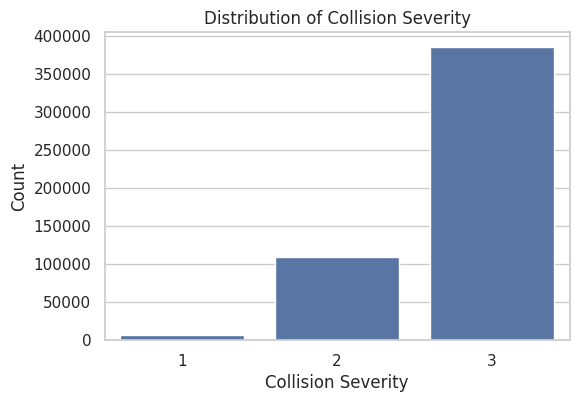

collision_severity
3    0.766686
2    0.218436
1    0.014879
Name: proportion, dtype: float64


In [ ]:
# Set style
sns.set(style="whitegrid")

# 1. Target Variable Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='collision_severity', data=collisions)
plt.title("Distribution of Collision Severity")
plt.xlabel("Collision Severity")
plt.ylabel("Count")
plt.show()

# Optional: normalized distribution (important for imbalance)
severity_ratio = collisions['collision_severity'].value_counts(normalize=True)
print(severity_ratio)

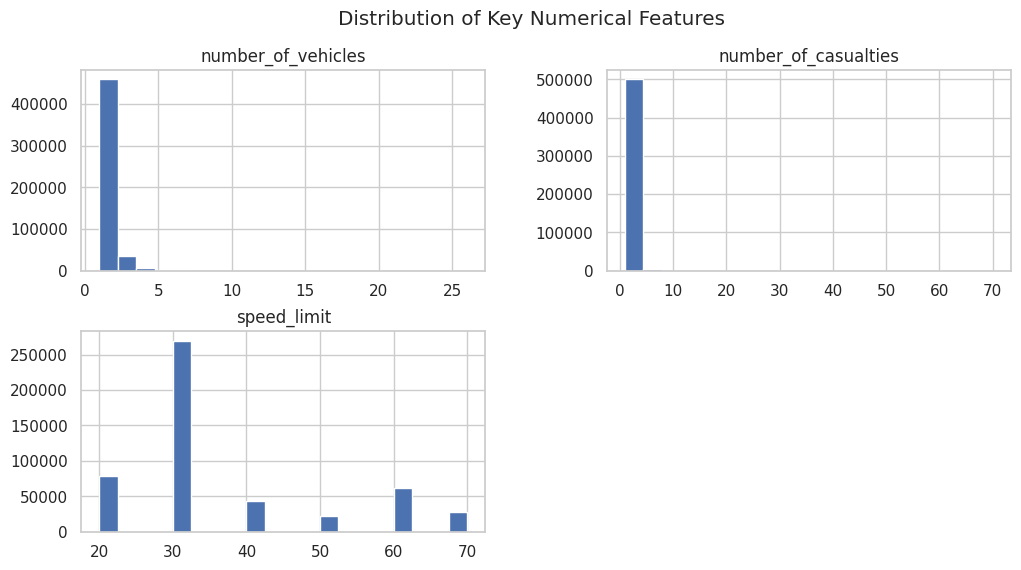

number_of_vehicles      1.784575
number_of_casualties    6.186144
speed_limit             1.106500
dtype: float64


In [ ]:
# -----------------------------
# 2. Numerical Features - Histogram
# -----------------------------
numerical_cols = ['number_of_vehicles', 'number_of_casualties', 'speed_limit']

collisions[numerical_cols].hist(bins=20,figsize=(12,6))
plt.suptitle("Distribution of Key Numerical Features")
plt.show()
# Optional: skewness check (important for interpretation)
print(collisions[numerical_cols].skew())

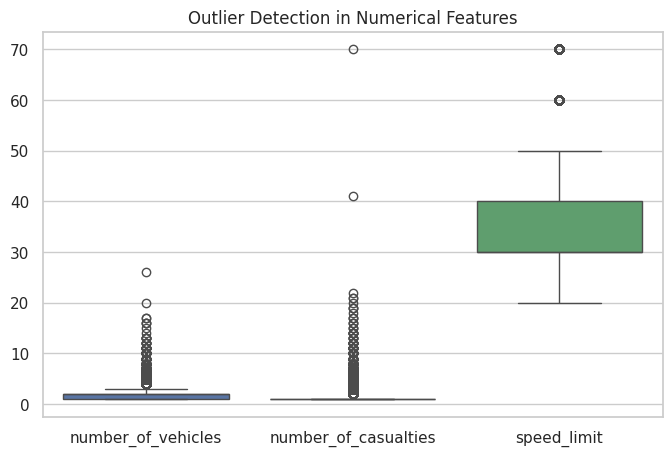

In [ ]:
# -----------------------------
# 3. Boxplot (Outlier Detection)
# -----------------------------
plt.figure(figsize=(8,5))
sns.boxplot(data=collisions[numerical_cols])
plt.title("Outlier Detection in Numerical Features")
plt.show()

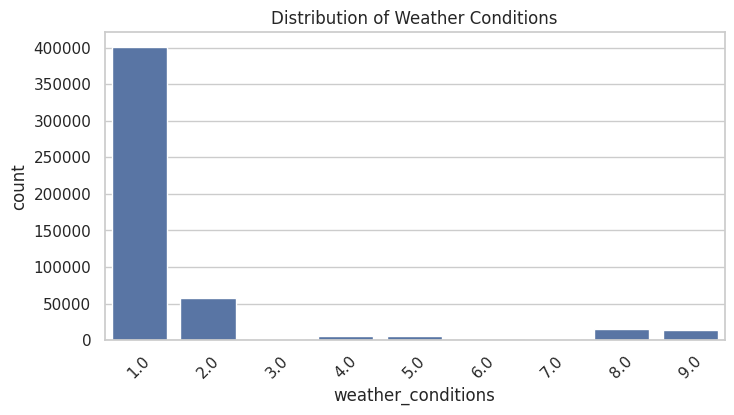

In [ ]:

# -----------------------------
# 4. Categorical Features Distribution
# -----------------------------

# Weather Conditions
plt.figure(figsize=(8,4))
sns.countplot(x='weather_conditions', data=collisions)
plt.title("Distribution of Weather Conditions")
plt.xticks(rotation=45)
plt.show()


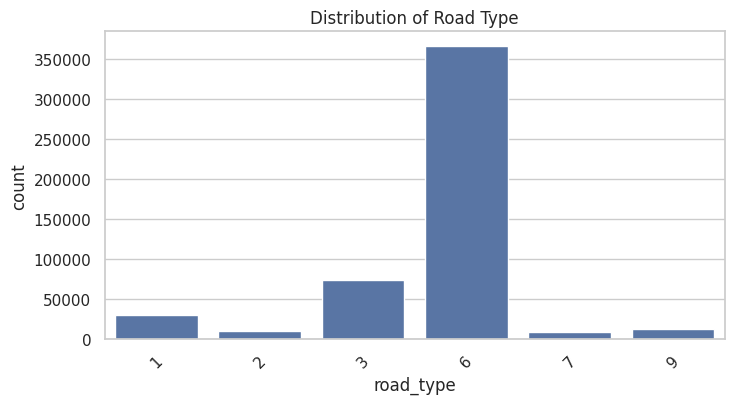

In [ ]:
# Road Type
plt.figure(figsize=(8,4))
sns.countplot(x='road_type', data=collisions)
plt.title("Distribution of Road Type")
plt.xticks(rotation=45)
plt.show()

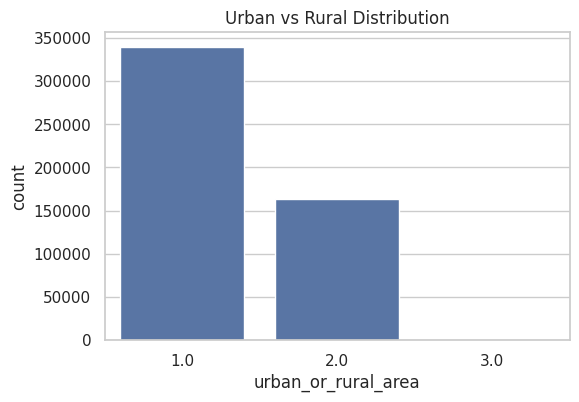

In [ ]:
# Urban vs Rural
plt.figure(figsize=(6,4))
sns.countplot(x='urban_or_rural_area', data=collisions)
plt.title("Urban vs Rural Distribution")
plt.show()


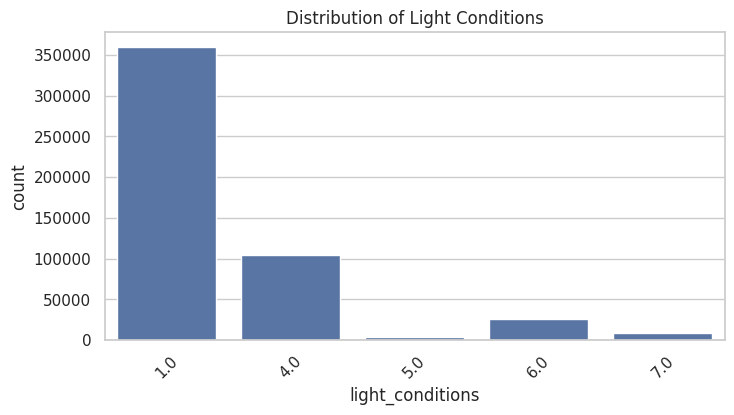

In [ ]:
# Light Conditions
plt.figure(figsize=(8,4))
sns.countplot(x='light_conditions', data=collisions)
plt.title("Distribution of Light Conditions")
plt.xticks(rotation=45)
plt.show()

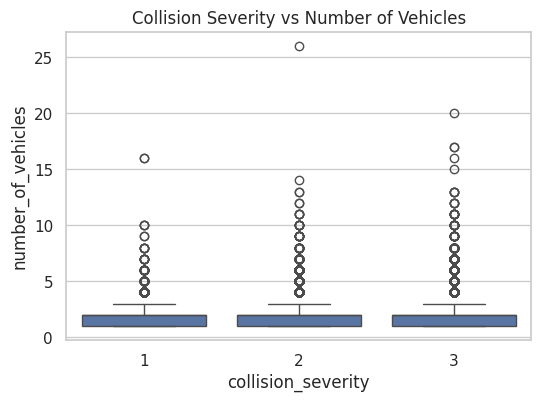

In [ ]:
#step11)Collision Severity vs Numerical Features (Boxplot)
# Severity vs Number of Vehicles
plt.figure(figsize=(6,4))
sns.boxplot(x='collision_severity', y='number_of_vehicles', data=collisions)
plt.title("Collision Severity vs Number of Vehicles")
plt.show()

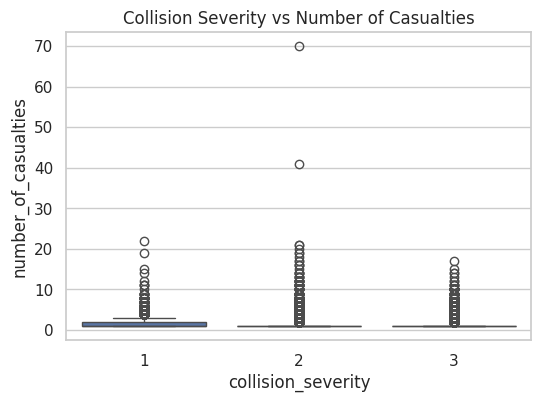

In [ ]:
# Severity vs Number of Casualties
plt.figure(figsize=(6,4))
sns.boxplot(x='collision_severity', y='number_of_casualties', data=collisions)
plt.title("Collision Severity vs Number of Casualties")
plt.show()

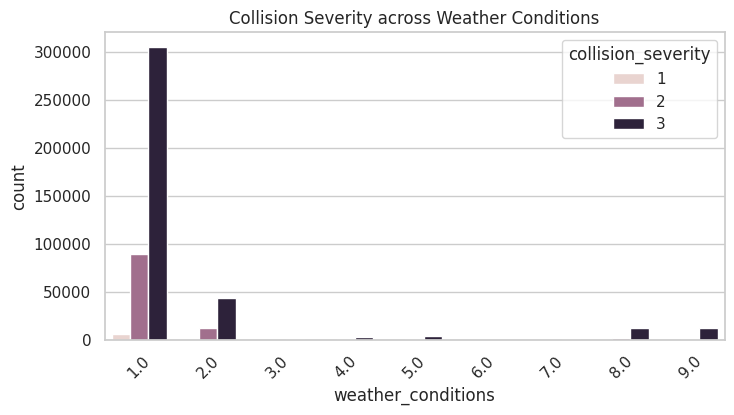

In [ ]:
#Collision Severity vs Categorical Features (Countplot)
# Weather vs Severity
plt.figure(figsize=(8,4))
sns.countplot(x='weather_conditions', hue='collision_severity', data=collisions)
plt.title("Collision Severity across Weather Conditions")
plt.xticks(rotation=45)
plt.show()

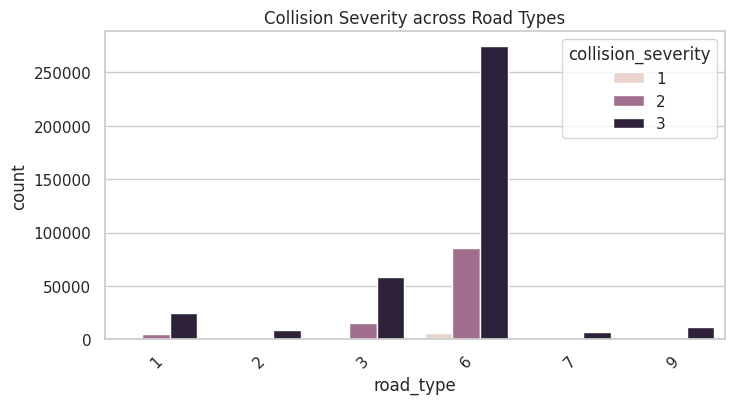

In [ ]:
# Road Type vs Severity
plt.figure(figsize=(8,4))
sns.countplot(x='road_type', hue='collision_severity', data=collisions)
plt.title("Collision Severity across Road Types")
plt.xticks(rotation=45)
plt.show()

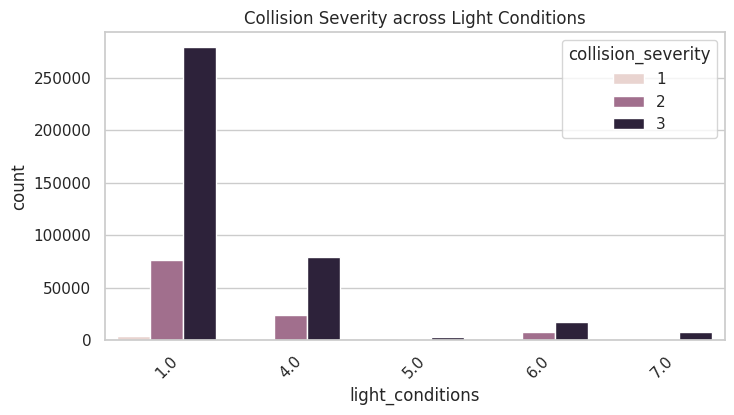

In [ ]:
# Light Conditions vs Severity
plt.figure(figsize=(8,4))
sns.countplot(x='light_conditions', hue='collision_severity', data=collisions)
plt.title("Collision Severity across Light Conditions")
plt.xticks(rotation=45)
plt.show()

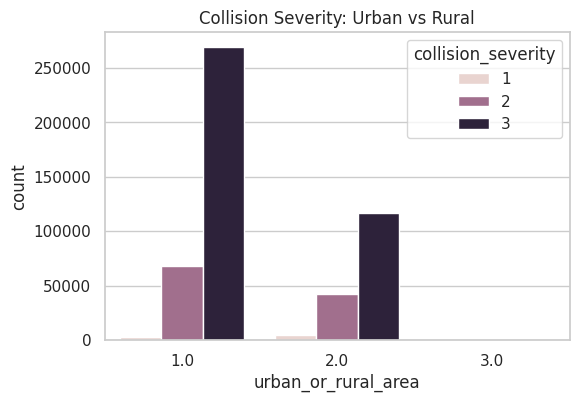

In [ ]:
# Urban vs Rural
plt.figure(figsize=(6,4))
sns.countplot(x='urban_or_rural_area', hue='collision_severity', data=collisions)
plt.title("Collision Severity: Urban vs Rural")
plt.show()

<Axes: xlabel='number_of_vehicles', ylabel='number_of_casualties'>

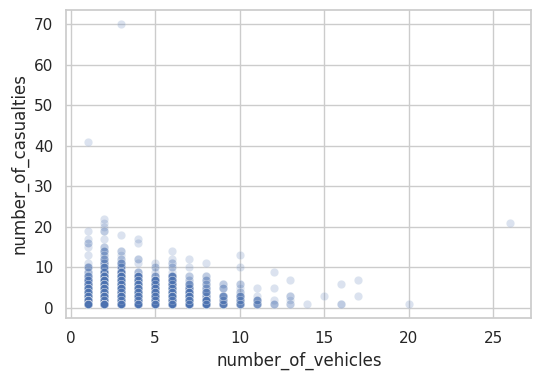

In [ ]:
#Scatter Plot (Numerical Relationship)
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='number_of_vehicles',
    y='number_of_casualties',
    data=collisions,
    alpha=0.2
)

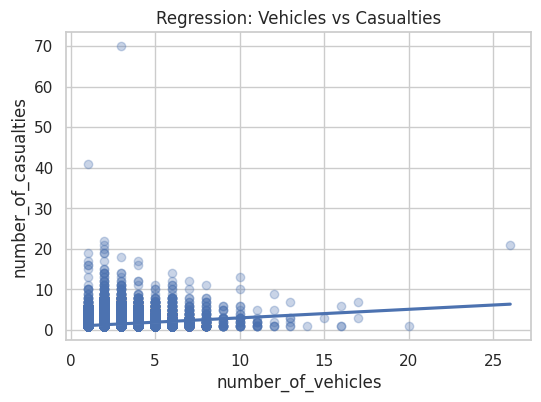

In [ ]:
# Regression Plot (Trend between Vehicles and Casualties)
# Confirms slight positive trend but large spread reduces predictive strength
plt.figure(figsize=(6,4))
sns.regplot(
    x='number_of_vehicles',
    y='number_of_casualties',
    data=collisions,
    scatter_kws={'alpha':0.3}
)
plt.title("Regression: Vehicles vs Casualties")
plt.show()

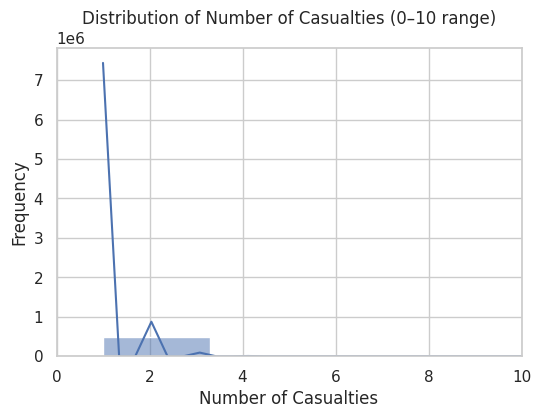

In [ ]:
# Histogram (Casualties Distribution - Right Skewed)
# Most accidents involve 0–2 casualties; extreme values are rare but present
plt.figure(figsize=(6,4))

sns.histplot(
    collisions['number_of_casualties'],
    kde=True,
    bins=30
)

plt.xlim(0, 10)  # focus on realistic range
plt.title("Distribution of Number of Casualties (0–10 range)")
plt.xlabel("Number of Casualties")
plt.ylabel("Frequency")
plt.show()

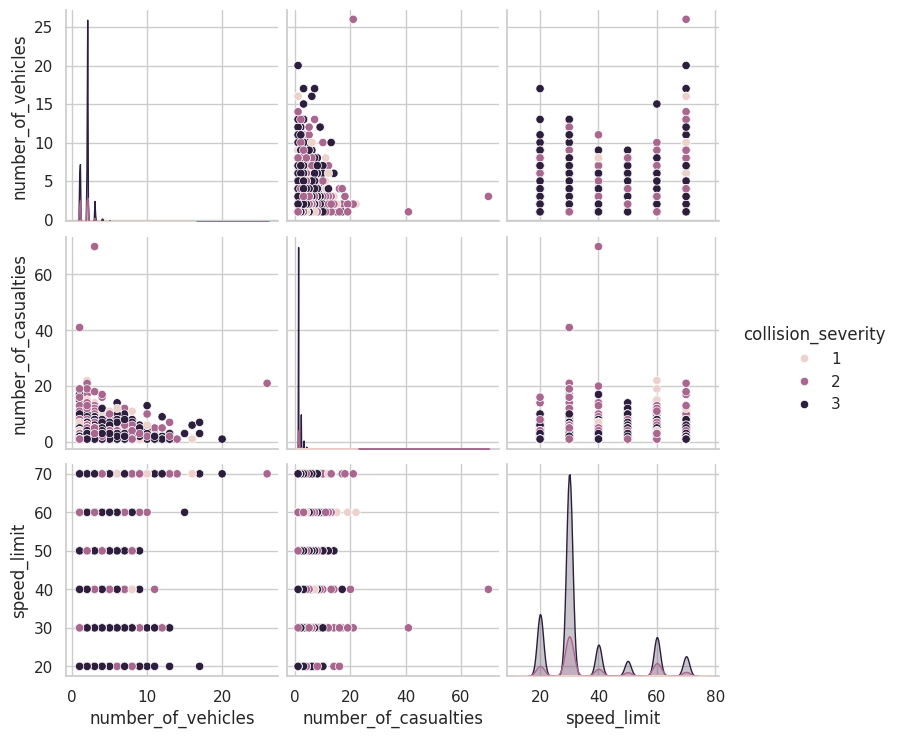

In [ ]:
# Pairplot (Multivariate Relationships)
# Most features show weak correlations → low multicollinearity
important_cols = [
    'collision_severity',
    'number_of_vehicles',
    'number_of_casualties',
    'speed_limit'
]

sns.pairplot(collisions[important_cols], hue='collision_severity')
plt.show()

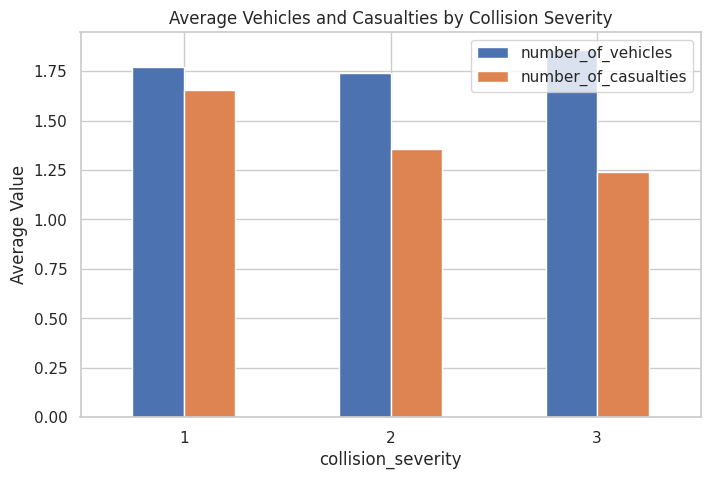

In [ ]:
# Grouped Analysis (Average Values by Severity)
# Casualties increase with severity; vehicles show minor variation
grouped = collisions.groupby('collision_severity')[
    ['number_of_vehicles', 'number_of_casualties']
].mean()

grouped.plot(kind='bar', figsize=(8,5))
plt.title("Average Vehicles and Casualties by Collision Severity")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.show()

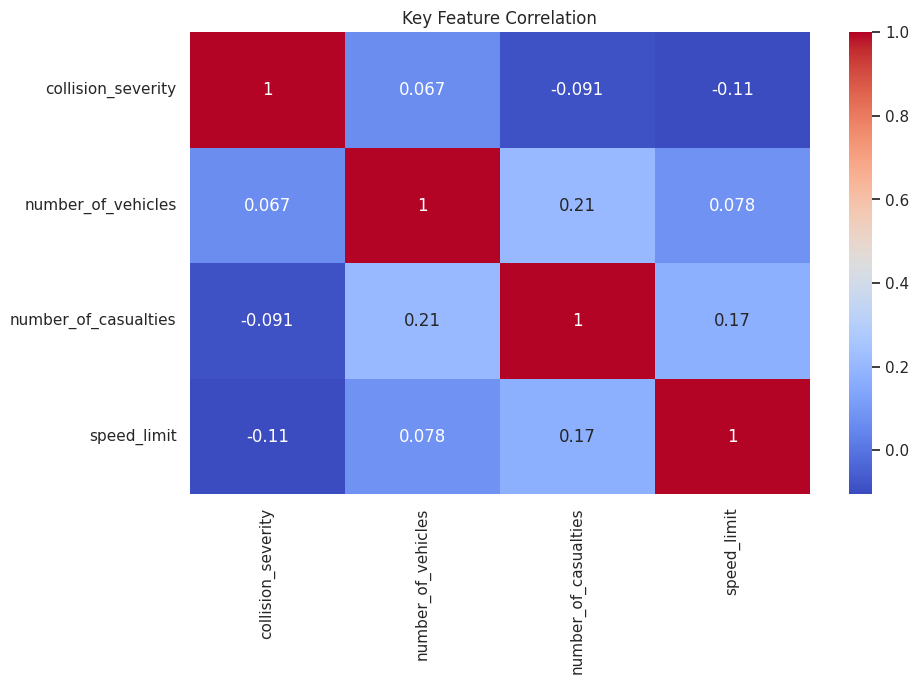

In [ ]:
# Show only important correlations
plt.figure(figsize=(10,6))

important_cols = [
    'collision_severity',
    'number_of_vehicles',
    'number_of_casualties',
    'speed_limit'
]

sns.heatmap(collisions[important_cols].corr(),
            annot=True, cmap='coolwarm')

plt.title("Key Feature Correlation")
plt.show()

In [ ]:
casualties.isnull().sum()

,0
collision_index,0
collision_year,0
collision_ref_no,0
vehicle_reference,0
casualty_reference,0
casualty_class,0
sex_of_casualty,0
age_of_casualty,0
casualty_severity,0
pedestrian_location,0


In [ ]:
collisions.isnull().sum()

,0
collision_index,0
collision_year,0
collision_ref_no,0
location_easting_osgr,0
location_northing_osgr,0
longitude,0
latitude,0
police_force,0
collision_severity,0
number_of_vehicles,0


In [ ]:
vehicles.isnull().sum()

,0
collision_index,0
collision_year,0
collision_ref_no,0
vehicle_reference,0
vehicle_type,0
towing_and_articulation,0
vehicle_manoeuvre,0
vehicle_direction_from,0
vehicle_direction_to,0
vehicle_location_restricted_lane,0


In [ ]:
missing = collisions.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

Series([], dtype: int64)


In [ ]:
missing = casualties.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

Series([], dtype: int64)


In [ ]:
missing = vehicles.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

Series([], dtype: int64)


In [ ]:
missing_percent = (casualties.isnull().mean() * 100)
print(missing_percent[missing_percent > 0].sort_values(ascending=False))

Series([], dtype: float64)


In [ ]:
missing_percent = (collisions.isnull().mean() * 100)
print(missing_percent[missing_percent > 0].sort_values(ascending=False))

Series([], dtype: float64)


In [ ]:
missing_percent = (vehicles.isnull().mean() * 100)
print(missing_percent[missing_percent > 0].sort_values(ascending=False))

Series([], dtype: float64)
